Found 2187 images belonging to 37 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,413 (12.62 MB)

 Trainable params: 3,309,413 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1529s 22s/step - accuracy: 0.0668 - loss: 3.5272
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 23s 330ms/step - accuracy: 0.1888 - loss: 3.0126
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 24s 342ms/step - accuracy: 0.2954 - loss: 2.5984
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 309ms/step - accuracy: 0.4005 - loss: 2.1991
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 23s 327ms/step - accuracy: 0.4705 - loss: 1.9443
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 296ms/step - accuracy: 0.5176 - loss: 1.7560
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 23s 334ms/step - accuracy: 0.5716 - loss: 1.5319
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 23s 329ms/step - accuracy: 0.6214 - loss: 1.3710
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 24s 342ms/step - accuracy: 0.6369 - loss: 1.2965
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.6767 - loss: 1.1601
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 23s 331ms/step - accuracy: 0.6767 - loss: 1.1090
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 21

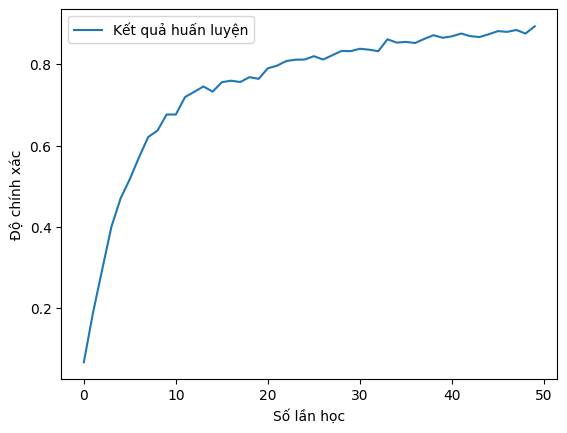

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/Ảnh selfie cho chiều t2 18 5"

# Kích thước ảnh và kích thước lô
img_width, img_height = 128, 128
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(37, activation="softmax") # 5 categories
])
# Biên dịch mô hình
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYÊN MÔ HÌNH CNN
epochs = 50
history = model.fit(train_generator, epochs=epochs)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
# plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực") # Removed as val_accuracy is not available without validation_data
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()
#lưu mô hình
model.save('mô hình nhận diện.h5')
with open("class_indices_cnn.json", "w") as f:
    json.dump(train_generator.class_indices, f)


In [ ]:
# ============================================================
# TEST NHẬN DIỆN KHUÔN MẶT TỪ ẢNH MỚI
# ============================================================
!pip install mtcnn opencv-python tensorflow -q
!pip install --upgrade h5py
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from keras.models import load_model
from keras.preprocessing.image import img_to_array
import h5py


# Thử mở file bằng h5py trước để kiểm tra tính toàn vẹn
try:
    with h5py.File('/content/mô hình nhận diện.h5', 'r') as f:
        print("File mở thành công bằng h5py!")
        # Nếu mở được, dùng lệnh load_model
        model = load_model("/content/mô hình nhận diện.h5")
except Exception as e:
    print(f"Lỗi khi mở file: {e}")


# ============================================================
# 2. LOAD LABEL
# ============================================================

with open("class_indices_cnn.json", "r") as f:

    class_indices = json.load(f)

# Đảo ngược dictionary
labels = {v:k for k,v in class_indices.items()}

# ============================================================
# 3. KHỞI TẠO FACE DETECTOR
# ============================================================

detector = MTCNN()

# ============================================================
# 4. ĐƯỜNG DẪN ẢNH TEST
# ============================================================

# Đổi thành ảnh muốn test
image_path = "/content/vĩ_1.jpg"

# ============================================================
# 5. ĐỌC ẢNH
# ============================================================

image = cv2.imread(image_path)

if image is None:
    raise Exception("Không đọc được ảnh!")

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ============================================================
# 6. DETECT FACE
# ============================================================

results = detector.detect_faces(rgb)

if len(results) == 0:

    print("Không phát hiện khuôn mặt!")

else:

    # ========================================================
    # LẤY KHUÔN MẶT ĐẦU TIÊN
    # ========================================================

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)

    face = rgb[y:y+h, x:x+w]

    # ========================================================
    # RESIZE
    # ========================================================

    face = cv2.resize(face, (160,160))

    # ========================================================
    # CHUẨN HÓA
    # ========================================================

    face = face.astype("float") / 255.0

    face = img_to_array(face)

    face = np.expand_dims(face, axis=0)

    # ========================================================
    # PREDICT
    # ========================================================

    prediction = model.predict(face)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    person_name = labels[predicted_class]


    # HIỂN THỊ KẾT QUẢ

    print("======================================")
    print("KẾT QUẢ NHẬN DIỆN")
    print("======================================")

    print("Người dự đoán:", person_name)

    print("Độ tin cậy:", round(confidence * 100, 2), "%")

    # ========================================================
    # VẼ KHUNG KHUÔN MẶT
    # ========================================================

    cv2.rectangle(
        rgb,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        3
    )

    cv2.putText(
        rgb,
        f"{person_name} ({round(confidence*100,2)}%)",
        (x,y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )

    # ========================================================
    # HIỂN THỊ ẢNH
    # ========================================================

    plt.figure(figsize=(8,8))

    plt.imshow(rgb)

    plt.axis("off")

    plt.show()